# 🔬 Surgical AI — Phase 2: Tracking + Timeline

**Builds on Phase 1.** Takes your trained YOLOv8 detector and adds:
- Upgraded training: `yolov8m` + 80 epochs + surgical-specific augmentations
- ByteTrack multi-object tracking — persistent tool IDs across frames
- Timestamped instrument log (CSV + JSON)
- Gantt-style timeline chart
- Annotated output video

---
| Step | What happens |
|---|---|
| Cell 1-2 | Re-train with yolov8m (skip if already done) |
| Cell 3-5 | ByteTrack tracking on video |
| Cell 6-7 | Build instrument timeline |
| Cell 8 | Gantt chart + PDF report |
| Cell 9 | Annotated video output |

## Cell 1 — Upgrade Training: YOLOv8m + 80 epochs
Skip this if you already re-trained. This upgrades from nano → medium and adds surgical augmentations.

In [1]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1192_endo_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1165_endo.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1184_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1198_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1152_endo.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1177_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1149_endo_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1164_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1187_endo_watershed_mask.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/frame_1216_endo.png
/kaggle/input/datasets/newslab/cholecseg8k/video18/video18_01139/

In [2]:
import os
import shutil
from pathlib import Path
from tqdm import tqdm

import cv2
import numpy as np
from PIL import Image

def mask_to_yolo_bboxes_clean(mask_path, class_id, img_w, img_h, target_pixel_value, min_area=400):
    """
    Convert a segmentation mask to YOLO format, using morphological closing 
    to fix fragmented masks and contours to filter out noise.
    """
    mask = np.array(Image.open(mask_path).convert('L'))
    
    # Create a binary mask (0 or 255) for OpenCV
    binary = (mask == target_pixel_value).astype(np.uint8) * 255
    
    # --- Morphological Closing ---
    # 40x40 kernel bridges massive gaps between mask fragments
    kernel = np.ones((40, 40), np.uint8)    
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    
    # Find continuous blobs (contours)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    yolo_boxes = []
    
    for contour in contours:
        area = cv2.contourArea(contour)
        
        # Ignore specks of noise 
        if area < min_area:
            continue
            
        x, y, w_pixels, h_pixels = cv2.boundingRect(contour)

        # Artifact Filter
        margin_x = img_w * 0.05
        margin_y = img_h * 0.05
        
        # This protects real tools that just happen to enter from the edge.
        if (x + w_pixels) < margin_x or (y + h_pixels) < margin_y or x > (img_w - margin_x) or y > (img_h - margin_y):
            continue
        
        cx = (x + w_pixels / 2) / img_w
        cy = (y + h_pixels / 2) / img_h
        w = w_pixels / img_w
        h = h_pixels / img_h
        
        cx, cy, w, h = [min(max(val, 0.0), 1.0) for val in [cx, cy, w, h]]
        
        yolo_boxes.append(f"{class_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        
    return yolo_boxes

INPUT_DIR = Path("/kaggle/input/datasets/newslab/cholecseg8k") 
OUTPUT_BASE = Path("/kaggle/working/yolo_dataset")

IMAGES_OUT = OUTPUT_BASE / "images"
LABELS_OUT = OUTPUT_BASE / "labels"

IMAGES_OUT.mkdir(parents=True, exist_ok=True)
LABELS_OUT.mkdir(parents=True, exist_ok=True)

CLASS_MAPPING = {
    0: 31,  # YOLO Class 0 = Grasper
    1: 32   # YOLO Class 1 = L-hook
}

all_images = list(INPUT_DIR.rglob("*_endo.png"))
print(f"Found {len(all_images)} images to process.")

saved_count = 0 

for img_path in tqdm(all_images, desc="Converting to YOLO Format"):
    mask_path = img_path.parent / img_path.name.replace("_endo.png", "_endo_mask.png")
    
    if not mask_path.exists():
        continue
        
    img = Image.open(img_path)
    img_w, img_h = img.size
    
    yolo_lines = []
    for class_id, pixel_val in CLASS_MAPPING.items():
        bboxes = mask_to_yolo_bboxes_clean(mask_path, class_id, img_w, img_h, target_pixel_value=pixel_val)
        if bboxes:
            yolo_lines.extend(bboxes)     
            
    # Only save if the frame actually contains a Grasper or L-hook
    if yolo_lines:
        parent_folder = img_path.parent.name 
        new_basename = f"{parent_folder}_{img_path.stem}" 
        
        new_img_path = IMAGES_OUT / f"{new_basename}.png"
        new_label_path = LABELS_OUT / f"{new_basename}.txt"
        
        shutil.copy(img_path, new_img_path)
        with open(new_label_path, "w") as f:
            f.write("\n".join(yolo_lines))
        
        saved_count += 1

print(f"\nDone! Saved {saved_count} annotated images to {OUTPUT_BASE}")

Found 8080 images to process.


Converting to YOLO Format: 100%|██████████| 8080/8080 [04:39<00:00, 28.93it/s]


Done! Saved 6419 annotated images to /kaggle/working/yolo_dataset


In [3]:
import os
import random
import shutil
import yaml
from pathlib import Path

# --- Paths ---
base_dir = Path("/kaggle/working/yolo_dataset")
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

# --- Create Train/Val Folders ---
for split in ['train', 'val']:
    (images_dir / split).mkdir(parents=True, exist_ok=True)
    (labels_dir / split).mkdir(parents=True, exist_ok=True)

# --- 80/20 Shuffle & Split ---
all_images = [f for f in images_dir.glob("*.png") if f.is_file()]
random.shuffle(all_images)

split_idx = int(len(all_images) * 0.8)
train_imgs = all_images[:split_idx]
val_imgs = all_images[split_idx:]

def move_files(file_list, split_name):
    for img_path in file_list:
        shutil.move(str(img_path), str(images_dir / split_name / img_path.name))
        
        label_path = labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            shutil.move(str(label_path), str(labels_dir / split_name / label_path.name))

print(f"Moving {len(train_imgs)} images to train...")
move_files(train_imgs, 'train')

print(f"Moving {len(val_imgs)} images to val...")
move_files(val_imgs, 'val')

# --- Generate data.yaml ---
yaml_content = {
    'path': str(base_dir),
    'train': 'images/train',
    'val': 'images/val',
    'nc': 2,
    'names': {
        0: 'Grasper', 
        1: 'L-hook'
    }
}

yaml_path = base_dir / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)
    
print(f"\nSuccess! data.yaml created at: {yaml_path}")

Moving 5135 images to train...
Moving 1284 images to val...

Success! data.yaml created at: /kaggle/working/yolo_dataset/data.yaml


In [4]:
!pip install ultralytics -q

from ultralytics import YOLO

# Load medium model — 25M params vs nano's 3M
model = YOLO('yolov8m.pt')

results = model.train(
    data='/kaggle/working/yolo_dataset/data.yaml',
    epochs=80,
    imgsz=640,
    batch=8,           # smaller batch — yolov8m needs more VRAM
    device=0,
    lr0=0.001,         # lower LR for fine-tuning
    patience=20,       # early stop if no improvement for 20 epochs
    project='Surgical_AI',
    name='v2_yolov8m',
    exist_ok=True,
    # Surgical-specific augmentations
    hsv_h=0.01,        # minimal hue shift (surgical light is consistent)
    hsv_s=0.7,         # saturation jitter — simulates blood/fluid changes
    hsv_v=0.4,         # brightness jitter — simulates smoke/lens fogging
    flipud=0.0,        # never flip vertically — tools always enter from top
    fliplr=0.5,        # horizontal flip OK
    degrees=5.0,       # small rotation — camera slightly rotates
    translate=0.1,
    scale=0.3,         # moderate scale — tool distance varies
    mosaic=0.5,        # reduce mosaic — tools are already small
    erasing=0.3,       # random erasing simulates occlusion by tissue
    plots=True,
    save=True,
    save_period=20,
    verbose=True,
)

print('\n✅ v2 training complete')
print(f'   Best weights: /kaggle/working/runs/detect/Surgical_AI/v2_yolov8m/weights/best.pt')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fracti

## Cell 2 — Evaluate v2 vs v1
Compare nano vs medium side by side.

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2936.7±494.4 MB/s, size: 362.5 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 1284 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1284/1284 414.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 81/81 3.3it/s 24.6s
                   all       1284       2117      0.959      0.907      0.958      0.807
               Grasper       1196       1667      0.963      0.924      0.975      0.841
                L-hook        424        450      0.955       0.89      0.942      0.773
Speed: 0.6ms preprocess, 14.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

  v2 YOLOv8m — VALIDATION RESULTS
  mAP50:       0.9583
  mAP50-95:    0.807

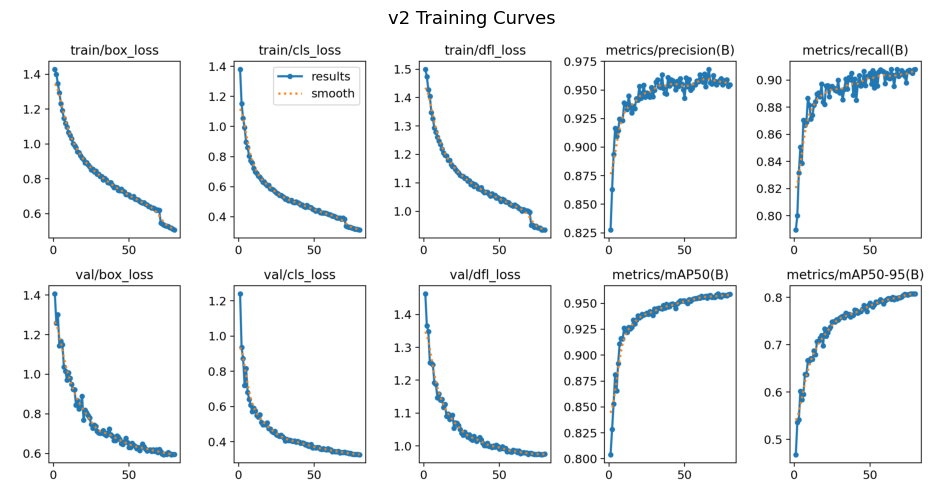

In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

v2_path = '/kaggle/working/runs/detect/Surgical_AI/v2_yolov8m/weights/best.pt'
model_v2 = YOLO(v2_path)

metrics = model_v2.val(
    data='/kaggle/working/yolo_dataset/data.yaml',
    imgsz=640,
    device=0,
    plots=True,
)

print('\n' + '='*50)
print('  v2 YOLOv8m — VALIDATION RESULTS')
print('='*50)
print(f'  mAP50:       {metrics.box.map50:.4f}')
print(f'  mAP50-95:    {metrics.box.map:.4f}')
print(f'  Precision:   {metrics.box.mp:.4f}')
print(f'  Recall:      {metrics.box.mr:.4f}')
print()
print('  v1 YOLOv8n reference:  mAP50=0.934  mAP50-95=0.767')

# Show training curves
run_dir = Path('/kaggle/working/runs/detect/Surgical_AI/v2_yolov8m')
results_png = run_dir / 'results.png'
if results_png.exists():
    img = mpimg.imread(str(results_png))
    plt.figure(figsize=(16, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('v2 Training Curves', fontsize=13)
    plt.show()

## Cell 3 — Install ByteTrack (boxmot)
boxmot is the cleanest YOLO-compatible tracking library. ByteTrack inside it is the best choice for surgical tools — handles occlusion well without needing appearance embeddings.

In [6]:
!pip install boxmot -q

import boxmot
print(f'✅ boxmot {boxmot.__version__} installed')

# Also need for video writing + plotting
!pip install fpdf2 -q
print('✅ fpdf2 installed (for PDF report)')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 94.2 MB/s eta 0:00:00
✅ boxmot 16.0.11 installed
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 10.6 MB/s eta 0:00:00
✅ fpdf2 installed (for PDF report)


## Cell 4 — Core Tracking Function
Runs YOLO detection + ByteTrack on every frame of a video.
Outputs: annotated video + raw tracking data per frame.

In [7]:
import cv2
import numpy as np
import torch
from pathlib import Path
from ultralytics import YOLO
from boxmot import ByteTrack
from collections import defaultdict

# ── Class config ─────────────────────────────────────────────────────────────
CLASS_NAMES  = {0: 'Grasper', 1: 'L-hook'}
CLASS_COLORS = {0: (0, 255, 0), 1: (0, 200, 255)}  # BGR: green, yellow

def run_tracking(video_path, model_path, output_video_path, conf=0.40):
    """
    Run YOLO + ByteTrack on a laparoscopic video.
    Returns raw_tracks: list of dicts, one per frame with detections.
    """
    model   = YOLO(model_path)
    tracker = ByteTrack()

    cap = cv2.VideoCapture(str(video_path))
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(
        str(output_video_path),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps, (width, height)
    )

    raw_tracks = []   # one entry per frame
    frame_idx  = 0

    print(f'Processing {total} frames at {fps:.1f}fps...')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        timestamp_sec = frame_idx / fps

        # ── YOLO detection ────────────────────────────────────────────────
        results = model.predict(frame, imgsz=640, conf=conf,
                                device=0, verbose=False)[0]

        # Build detection array for ByteTrack: [x1,y1,x2,y2,conf,class]
        dets = []
        if results.boxes is not None and len(results.boxes) > 0:
            for box in results.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                c   = float(box.conf[0])
                cls = int(box.cls[0])
                dets.append([x1, y1, x2, y2, c, cls])

        dets_np = np.array(dets) if dets else np.empty((0, 6))

        # ── ByteTrack update ──────────────────────────────────────────────
        # Returns: [x1,y1,x2,y2,track_id,conf,cls,idx]
        tracks = tracker.update(dets_np, frame)

        frame_data = {
            'frame_idx':     frame_idx,
            'timestamp_sec': round(timestamp_sec, 3),
            'detections':    []
        }

        annotated = frame.copy()

        if len(tracks) > 0:
            for t in tracks:
                x1, y1, x2, y2 = int(t[0]), int(t[1]), int(t[2]), int(t[3])
                track_id = int(t[4])
                conf_val = float(t[5])
                cls_id   = int(t[6])

                tool_name = CLASS_NAMES.get(cls_id, f'Class{cls_id}')
                color     = CLASS_COLORS.get(cls_id, (255, 255, 255))

                frame_data['detections'].append({
                    'track_id':  track_id,
                    'tool':      tool_name,
                    'class_id':  cls_id,
                    'conf':      round(conf_val, 3),
                    'bbox':      [x1, y1, x2, y2]
                })

                # Draw bounding box
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

                # Label: tool name + track ID + confidence
                label = f'{tool_name} #{track_id} {conf_val:.2f}'
                (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
                cv2.rectangle(annotated, (x1, y1 - lh - 8), (x1 + lw + 4, y1), color, -1)
                cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)

        # Frame counter overlay
        ts_str = f'{int(timestamp_sec//60):02d}:{timestamp_sec%60:05.2f}'
        cv2.putText(annotated, f'Frame {frame_idx}  {ts_str}',
                    (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (255, 255, 255), 2)

        raw_tracks.append(frame_data)
        out.write(annotated)
        frame_idx += 1

        if frame_idx % 100 == 0:
            print(f'  {frame_idx}/{total} frames ({100*frame_idx/total:.1f}%)')

    cap.release()
    out.release()
    print(f'\n✅ Tracking complete. Annotated video: {output_video_path}')
    return raw_tracks, fps

print('✅ Tracking function defined')

✅ Tracking function defined


## Cell 5 — Run Tracking on Your Video
Upload a laparoscopic video (.mp4) via Kaggle's data panel, then set the path below.

In [8]:
from pathlib import Path
import os

# ── Set your paths ────────────────────────────────────────────────────────────
MODEL_PATH  = '/kaggle/working/runs/detect/Surgical_AI/v2_yolov8m/weights/best.pt'

# Change this to your uploaded video path
# If you don't have a video yet, Cell 5b below creates a test video from val images
VIDEO_PATH  = '/kaggle/input/your-video/surgery_clip.mp4'  

OUTPUT_DIR  = Path('/kaggle/working/tracking_output')
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_VIDEO = OUTPUT_DIR / 'tracked_surgery.mp4'

if not Path(VIDEO_PATH).exists():
    print('⚠️  Video not found at:', VIDEO_PATH)
    print('   Run Cell 5b to create a test video from your validation images first.')
else:
    raw_tracks, fps = run_tracking(
        video_path=VIDEO_PATH,
        model_path=MODEL_PATH,
        output_video_path=OUTPUT_VIDEO,
        conf=0.40
    )
    print(f'   Total frames tracked: {len(raw_tracks)}')
    total_dets = sum(len(f["detections"]) for f in raw_tracks)
    print(f'   Total detections:     {total_dets}')

⚠️  Video not found at: /kaggle/input/your-video/surgery_clip.mp4
   Run Cell 5b to create a test video from your validation images first.


## Cell 5b — Build Test Video from Val Images (if no video available)

In [9]:
import cv2
import os
from pathlib import Path

# Stitch your val images into a test video at 5fps
val_images = sorted(Path('/kaggle/working/yolo_dataset/images/val').glob('*.png'))[:300]

if not val_images:
    print('No val images found.')
else:
    test_video_path = '/kaggle/working/tracking_output/test_clip.mp4'
    Path('/kaggle/working/tracking_output').mkdir(exist_ok=True)

    sample_img = cv2.imread(str(val_images[0]))
    h, w = sample_img.shape[:2]
    fps_out = 5.0  # slow enough to see tool detections clearly

    writer = cv2.VideoWriter(
        test_video_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps_out, (w, h)
    )

    for img_path in val_images:
        frame = cv2.imread(str(img_path))
        writer.write(frame)

    writer.release()
    print(f'✅ Test video created: {test_video_path}')
    print(f'   {len(val_images)} frames at {fps_out}fps')

    # Now run tracking on it
    VIDEO_PATH = test_video_path
    MODEL_PATH = '/kaggle/working/runs/detect/Surgical_AI/v2_yolov8m/weights/best.pt'
    OUTPUT_VIDEO = Path('/kaggle/working/tracking_output/tracked_surgery.mp4')

    raw_tracks, fps = run_tracking(
        video_path=VIDEO_PATH,
        model_path=MODEL_PATH,
        output_video_path=OUTPUT_VIDEO,
        conf=0.40
    )
    print(f'\n   Total frames tracked: {len(raw_tracks)}')

SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30


✅ Test video created: /kaggle/working/tracking_output/test_clip.mp4
   300 frames at 5.0fps
Processing 300 frames at 5.0fps...
  100/300 frames (33.3%)
  200/300 frames (66.7%)
  300/300 frames (100.0%)

✅ Tracking complete. Annotated video: /kaggle/working/tracking_output/tracked_surgery.mp4

   Total frames tracked: 300


## Cell 6 — Build Instrument Timeline
Converts raw per-frame detections into structured appearance intervals:
`{tool, track_id, start_sec, end_sec, duration_sec, mean_conf}`

In [10]:
import pandas as pd
import json
from collections import defaultdict

def build_instrument_timeline(raw_tracks, fps, gap_tolerance_sec=1.5):
    """
    Converts per-frame tracking data into instrument appearance intervals.
    
    gap_tolerance_sec: if a tool disappears for less than this, merge the intervals.
    This handles momentary occlusion without creating many tiny fragments.
    """
    # Group detections by track_id
    track_history = defaultdict(list)

    for frame_data in raw_tracks:
        for det in frame_data['detections']:
            track_history[det['track_id']].append({
                'timestamp_sec': frame_data['timestamp_sec'],
                'frame_idx':     frame_data['frame_idx'],
                'tool':          det['tool'],
                'class_id':      det['class_id'],
                'conf':          det['conf'],
            })

    intervals = []

    for track_id, appearances in track_history.items():
        appearances.sort(key=lambda x: x['timestamp_sec'])
        tool_name = appearances[0]['tool']
        class_id  = appearances[0]['class_id']

        # Build raw intervals (consecutive frames)
        raw_intervals = []
        seg_start  = appearances[0]
        seg_frames = [appearances[0]]

        for i in range(1, len(appearances)):
            gap = appearances[i]['timestamp_sec'] - appearances[i-1]['timestamp_sec']
            if gap <= gap_tolerance_sec:
                seg_frames.append(appearances[i])
            else:
                raw_intervals.append((seg_start, seg_frames[-1], seg_frames))
                seg_start  = appearances[i]
                seg_frames = [appearances[i]]

        raw_intervals.append((seg_start, seg_frames[-1], seg_frames))

        for start_entry, end_entry, frames in raw_intervals:
            duration = end_entry['timestamp_sec'] - start_entry['timestamp_sec']
            if duration < 0.5:
                continue  # skip sub-half-second blips

            mean_conf = round(sum(f['conf'] for f in frames) / len(frames), 3)

            intervals.append({
                'track_id':    track_id,
                'tool':        tool_name,
                'class_id':    class_id,
                'start_sec':   round(start_entry['timestamp_sec'], 2),
                'end_sec':     round(end_entry['timestamp_sec'], 2),
                'duration_sec':round(duration, 2),
                'mean_conf':   mean_conf,
                'frame_count': len(frames),
            })

    # Sort by start time
    intervals.sort(key=lambda x: x['start_sec'])
    return intervals


def format_time(seconds):
    m = int(seconds // 60)
    s = seconds % 60
    return f'{m:02d}:{s:05.2f}'


# Build the timeline
timeline = build_instrument_timeline(raw_tracks, fps, gap_tolerance_sec=1.5)

# Save as CSV
df = pd.DataFrame(timeline)
csv_path = '/kaggle/working/tracking_output/instrument_timeline.csv'
df.to_csv(csv_path, index=False)

# Save as JSON
json_path = '/kaggle/working/tracking_output/instrument_timeline.json'
with open(json_path, 'w') as f:
    json.dump(timeline, f, indent=2)

print(f'✅ Timeline built: {len(timeline)} instrument appearances')
print(f'   CSV:  {csv_path}')
print(f'   JSON: {json_path}')
print()

# Print human-readable summary
print('INSTRUMENT APPEARANCE LOG')
print('-' * 65)
print(f'{"Tool":<14} {"Track ID":<10} {"Start":<10} {"End":<10} {"Duration":<12} {"Conf"}')
print('-' * 65)
for entry in timeline:
    print(f'{entry["tool"]:<14} #{entry["track_id"]:<9} '
          f'{format_time(entry["start_sec"]):<10} '
          f'{format_time(entry["end_sec"]):<10} '
          f'{entry["duration_sec"]:>6.1f}s      '
          f'{entry["mean_conf"]:.3f}')

✅ Timeline built: 20 instrument appearances
   CSV:  /kaggle/working/tracking_output/instrument_timeline.csv
   JSON: /kaggle/working/tracking_output/instrument_timeline.json

INSTRUMENT APPEARANCE LOG
-----------------------------------------------------------------
Tool           Track ID   Start      End        Duration     Conf
-----------------------------------------------------------------
Grasper        #2         00:00.40   00:04.20      3.8s      0.921
Grasper        #7         00:05.60   00:09.80      4.2s      0.784
Grasper        #10        00:11.00   00:25.00     14.0s      0.899
Grasper        #11        00:11.00   00:14.40      3.4s      0.746
L-hook         #12        00:11.00   00:11.60      0.6s      0.820
L-hook         #13        00:12.00   00:27.60     15.6s      0.888
Grasper        #14        00:15.20   00:22.60      7.4s      0.866
Grasper        #15        00:25.40   00:29.20      3.8s      0.920
Grasper        #16        00:29.40   00:30.80      1.4s      0.9

## Cell 7 — Summary Statistics
Per-tool totals: time in frame, appearance count, mean confidence.

In [11]:
import pandas as pd

df = pd.read_csv('/kaggle/working/tracking_output/instrument_timeline.csv')

total_video_sec = raw_tracks[-1]['timestamp_sec'] if raw_tracks else 0

print('='*55)
print('  SURGICAL INSTRUMENT SUMMARY')
print('='*55)
print(f'  Video duration:   {format_time(total_video_sec)}')
print(f'  Total frames:     {len(raw_tracks)}')
print(f'  Total appearances:{len(df)}')
print()

summary = df.groupby('tool').agg(
    total_time_sec  = ('duration_sec', 'sum'),
    appearances     = ('track_id', 'count'),
    mean_confidence = ('mean_conf', 'mean'),
    longest_sec     = ('duration_sec', 'max'),
).round(2)

summary['pct_of_video'] = (summary['total_time_sec'] / total_video_sec * 100).round(1)
summary['mean_confidence'] = summary['mean_confidence'].round(3)

print(summary.to_string())
print()

# Save summary
summary.to_csv('/kaggle/working/tracking_output/instrument_summary.csv')
print('✅ Summary saved to /kaggle/working/tracking_output/instrument_summary.csv')

  SURGICAL INSTRUMENT SUMMARY
  Video duration:   00:59.80
  Total frames:     300
  Total appearances:20

         total_time_sec  appearances  mean_confidence  longest_sec  pct_of_video
tool                                                                            
Grasper            49.4           15             0.87         14.0          82.6
L-hook             42.0            5             0.87         15.6          70.2

✅ Summary saved to /kaggle/working/tracking_output/instrument_summary.csv


## Cell 8 — Gantt Timeline Chart
Visualises when each tool was active, colour-coded by tool type.

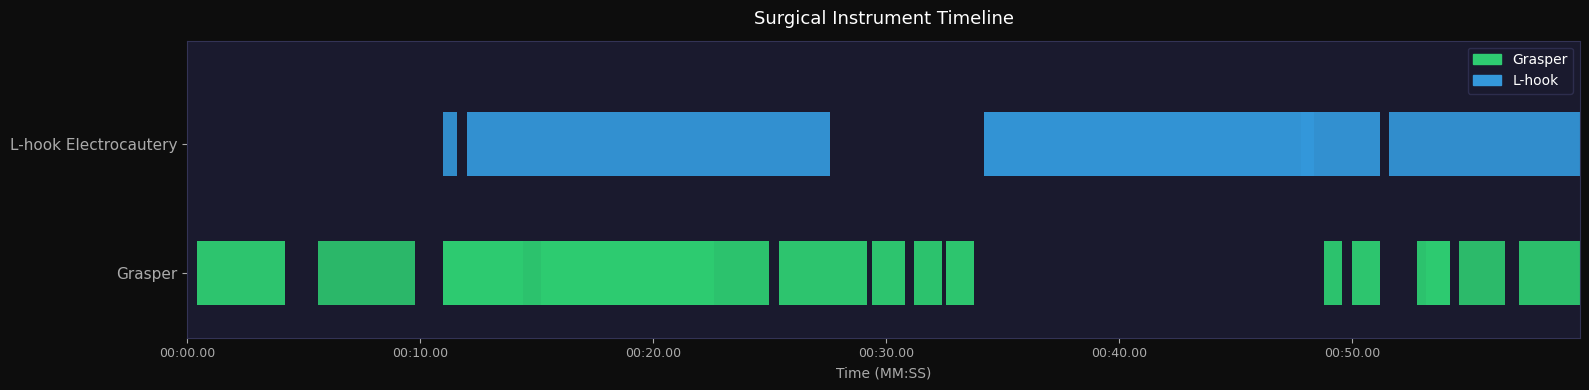

✅ Timeline chart saved: /kaggle/working/tracking_output/instrument_timeline_chart.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/working/tracking_output/instrument_timeline.csv')

TOOL_COLORS = {'Grasper': '#2ecc71', 'L-hook': '#3498db'}
TOOL_Y      = {'Grasper': 1,         'L-hook': 2}
YTICKLABELS = {1: 'Grasper', 2: 'L-hook Electrocautery'}

total_video_sec = raw_tracks[-1]['timestamp_sec'] if raw_tracks else df['end_sec'].max()

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a2e')

for _, row in df.iterrows():
    tool  = row['tool']
    y     = TOOL_Y.get(tool, 3)
    color = TOOL_COLORS.get(tool, '#e74c3c')
    alpha = min(1.0, 0.5 + row['mean_conf'] * 0.5)  # higher conf = more opaque

    ax.barh(
        y, row['duration_sec'],
        left=row['start_sec'],
        height=0.5,
        color=color,
        alpha=alpha,
        edgecolor='none',
    )

# X axis: time in MM:SS
tick_interval = max(10, int(total_video_sec / 10))
xticks = np.arange(0, total_video_sec + tick_interval, tick_interval)
ax.set_xticks(xticks)
ax.set_xticklabels([format_time(t) for t in xticks],
                    color='#aaaaaa', fontsize=9)

ax.set_yticks(list(TOOL_Y.values()))
ax.set_yticklabels([YTICKLABELS[y] for y in TOOL_Y.values()],
                    color='white', fontsize=11)
ax.set_xlim(0, total_video_sec)
ax.set_ylim(0.5, 2.8)
ax.set_xlabel('Time (MM:SS)', color='#aaaaaa', fontsize=10)
ax.set_title('Surgical Instrument Timeline', color='white', fontsize=13, pad=12)
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

# Legend
legend_patches = [
    mpatches.Patch(color=color, label=tool)
    for tool, color in TOOL_COLORS.items()
]
ax.legend(handles=legend_patches, loc='upper right',
          facecolor='#1a1a2e', edgecolor='#333355',
          labelcolor='white', fontsize=10)

plt.tight_layout()
chart_path = '/kaggle/working/tracking_output/instrument_timeline_chart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ Timeline chart saved: {chart_path}')

## Cell 9 — Generate PDF Surgical Report
Produces a downloadable PDF with summary stats + timeline chart.

In [13]:
from fpdf import FPDF
import pandas as pd
from datetime import datetime

df_timeline = pd.read_csv('/kaggle/working/tracking_output/instrument_timeline.csv')
df_summary  = pd.read_csv('/kaggle/working/tracking_output/instrument_summary.csv')
total_sec   = raw_tracks[-1]['timestamp_sec'] if raw_tracks else 0

class SurgicalReport(FPDF):
    def header(self):
        self.set_fill_color(15, 15, 46)
        self.rect(0, 0, 210, 28, 'F')
        self.set_text_color(255, 255, 255)
        self.set_font('Helvetica', 'B', 16)
        self.set_xy(10, 8)
        self.cell(0, 10, 'Surgical Intelligence Report', ln=True)
        self.set_font('Helvetica', '', 9)
        self.set_xy(10, 18)
        self.cell(0, 6, f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}  |  Model: YOLOv8m + ByteTrack')
        self.set_text_color(0, 0, 0)
        self.ln(18)

    def footer(self):
        self.set_y(-12)
        self.set_font('Helvetica', 'I', 8)
        self.set_text_color(150, 150, 150)
        self.cell(0, 10, f'Page {self.page_no()}  |  For research and training use only', align='C')

pdf = SurgicalReport()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

# ── Section 1: Video summary ──────────────────────────────────────────────────
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(26, 86, 160)
pdf.cell(0, 8, '1. Procedure Summary', ln=True)
pdf.set_draw_color(26, 86, 160)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(4)

pdf.set_font('Helvetica', '', 11)
pdf.set_text_color(0, 0, 0)
stats = [
    ('Procedure type',     'Laparoscopic Cholecystectomy'),
    ('Video duration',     format_time(total_sec)),
    ('Total frames',       str(len(raw_tracks))),
    ('Instruments tracked',str(df_timeline['tool'].nunique())),
    ('Total appearances',  str(len(df_timeline))),
]
for label, value in stats:
    pdf.set_font('Helvetica', 'B', 10)
    pdf.cell(60, 7, label + ':', border=0)
    pdf.set_font('Helvetica', '', 10)
    pdf.cell(0, 7, value, ln=True)

pdf.ln(6)

# ── Section 2: Per-instrument stats table ─────────────────────────────────────
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(26, 86, 160)
pdf.cell(0, 8, '2. Instrument Statistics', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(4)

# Table header
headers = ['Instrument', 'Total Time', '% of Video', 'Appearances', 'Mean Conf']
col_w   = [55, 35, 32, 35, 33]
pdf.set_fill_color(26, 86, 160)
pdf.set_text_color(255, 255, 255)
pdf.set_font('Helvetica', 'B', 10)
for h, w in zip(headers, col_w):
    pdf.cell(w, 8, h, border=1, fill=True, align='C')
pdf.ln()

pdf.set_text_color(0, 0, 0)
fill = False
for _, row in df_summary.iterrows():
    pdf.set_fill_color(235, 242, 252) if fill else pdf.set_fill_color(255, 255, 255)
    pdf.set_font('Helvetica', '', 10)
    vals = [
        str(row.get('tool', row.name)),
        format_time(float(row['total_time_sec'])),
        f"{row['pct_of_video']:.1f}%",
        str(int(row['appearances'])),
        f"{row['mean_confidence']:.3f}",
    ]
    for v, w in zip(vals, col_w):
        pdf.cell(w, 7, v, border=1, fill=True, align='C')
    pdf.ln()
    fill = not fill

pdf.ln(8)

# ── Section 3: Timeline chart ─────────────────────────────────────────────────
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(26, 86, 160)
pdf.cell(0, 8, '3. Instrument Timeline', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(4)

chart_path = '/kaggle/working/tracking_output/instrument_timeline_chart.png'
if Path(chart_path).exists():
    pdf.image(chart_path, x=10, w=190)

pdf.ln(6)

# ── Section 4: Detailed appearance log ───────────────────────────────────────
pdf.add_page()
pdf.set_font('Helvetica', 'B', 12)
pdf.set_text_color(26, 86, 160)
pdf.cell(0, 8, '4. Detailed Appearance Log', ln=True)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(4)

log_headers = ['Tool', 'Track ID', 'Start', 'End', 'Duration', 'Confidence']
log_widths  = [40, 25, 30, 30, 30, 35]

pdf.set_fill_color(26, 86, 160)
pdf.set_text_color(255, 255, 255)
pdf.set_font('Helvetica', 'B', 9)
for h, w in zip(log_headers, log_widths):
    pdf.cell(w, 7, h, border=1, fill=True, align='C')
pdf.ln()

pdf.set_text_color(0, 0, 0)
fill = False
for entry in timeline:
    pdf.set_fill_color(235, 242, 252) if fill else pdf.set_fill_color(255, 255, 255)
    pdf.set_font('Helvetica', '', 9)
    row_vals = [
        entry['tool'],
        f"#{entry['track_id']}",
        format_time(entry['start_sec']),
        format_time(entry['end_sec']),
        f"{entry['duration_sec']:.1f}s",
        f"{entry['mean_conf']:.3f}",
    ]
    for v, w in zip(row_vals, log_widths):
        pdf.cell(w, 6, v, border=1, fill=True, align='C')
    pdf.ln()
    fill = not fill

# Save PDF
pdf_path = '/kaggle/working/tracking_output/surgical_report.pdf'
pdf.output(pdf_path)
print(f'✅ PDF report saved: {pdf_path}')

✅ PDF report saved: /kaggle/working/tracking_output/surgical_report.pdf


/tmp/ipykernel_24/140427074.py:16: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, 'Surgical Intelligence Report', ln=True)
/tmp/ipykernel_24/140427074.py:36: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, '1. Procedure Summary', ln=True)
/tmp/ipykernel_24/140427074.py:54: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 7, value, ln=True)
/tmp/ipykernel_24/140427074.py:61: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 8, '2. Instrument Statistics', ln=True)
/tmp/ipykernel_24/140427074.py:97: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos

## Cell 10 — Re-encode Video for Playback + Show Outputs

In [14]:
import subprocess
from pathlib import Path

# Re-encode to H264 for browser/VLC compatibility
raw_video  = '/kaggle/working/tracking_output/tracked_surgery.mp4'
h264_video = '/kaggle/working/tracking_output/tracked_surgery_h264.mp4'

result = subprocess.run([
    'ffmpeg', '-y', '-i', raw_video,
    '-vcodec', 'libx264', '-crf', '23', '-preset', 'fast',
    h264_video
], capture_output=True, text=True)

if Path(h264_video).exists():
    size_mb = Path(h264_video).stat().st_size / 1e6
    print(f'✅ H264 video: {h264_video} ({size_mb:.1f} MB)')
else:
    print('⚠️  ffmpeg re-encode failed, use the raw mp4v version')
    print(result.stderr[-500:])

# List all outputs
print('\n📁 All output files:')
for f in sorted(Path('/kaggle/working/tracking_output').iterdir()):
    size = f.stat().st_size / 1e6
    print(f'   {f.name:<45} {size:.2f} MB')

print('\n✅ Phase 2 complete!')
print('   Next → Phase 3: Surgical phase recognition (CNN-LSTM on CholecT50)')

✅ H264 video: /kaggle/working/tracking_output/tracked_surgery_h264.mp4 (7.9 MB)

📁 All output files:
   instrument_summary.csv                        0.00 MB
   instrument_timeline.csv                       0.00 MB
   instrument_timeline.json                      0.00 MB
   instrument_timeline_chart.png                 0.03 MB
   surgical_report.pdf                           0.04 MB
   test_clip.mp4                                 10.32 MB
   tracked_surgery.mp4                           11.85 MB
   tracked_surgery_h264.mp4                      7.88 MB

✅ Phase 2 complete!
   Next → Phase 3: Surgical phase recognition (CNN-LSTM on CholecT50)
